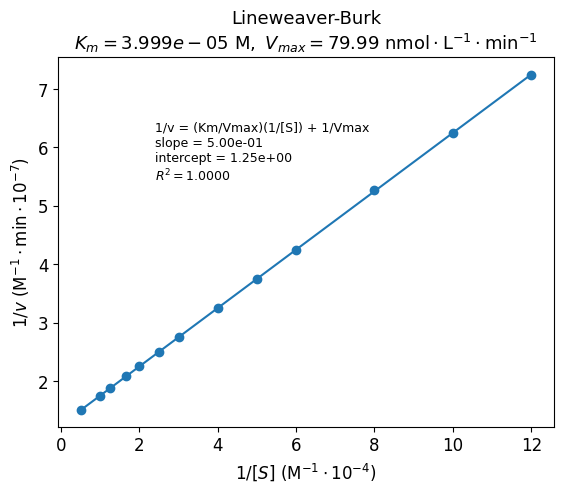

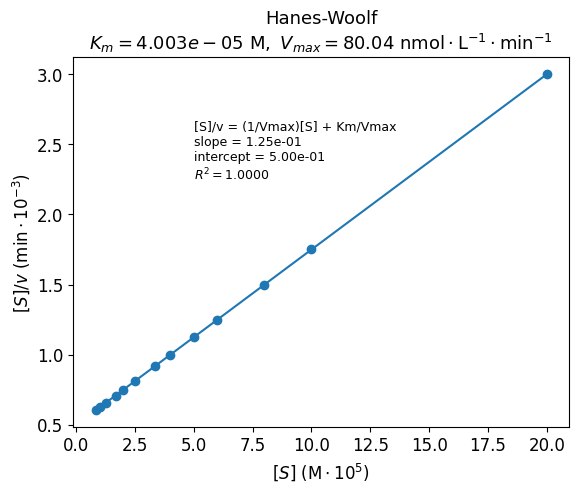

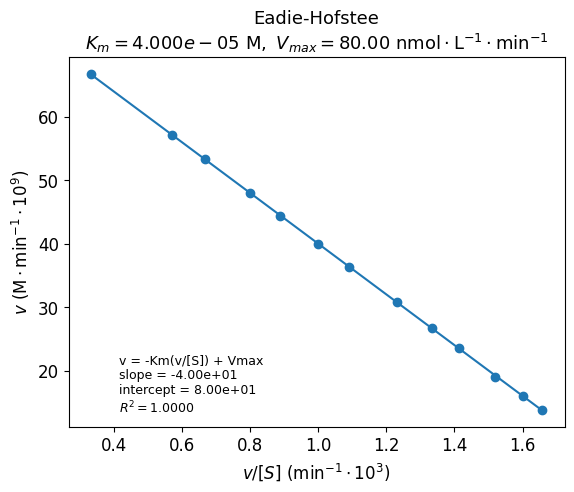

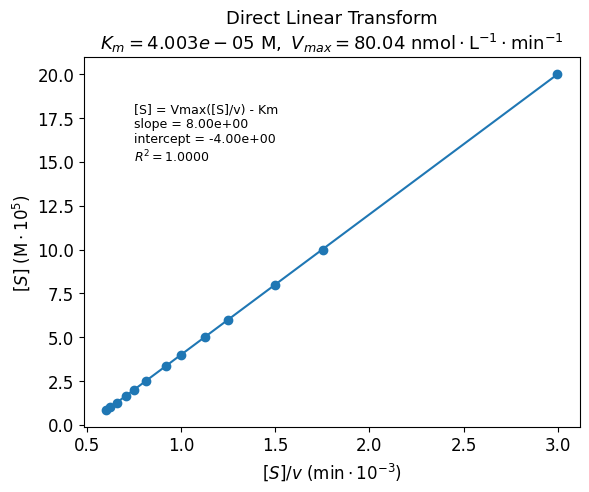

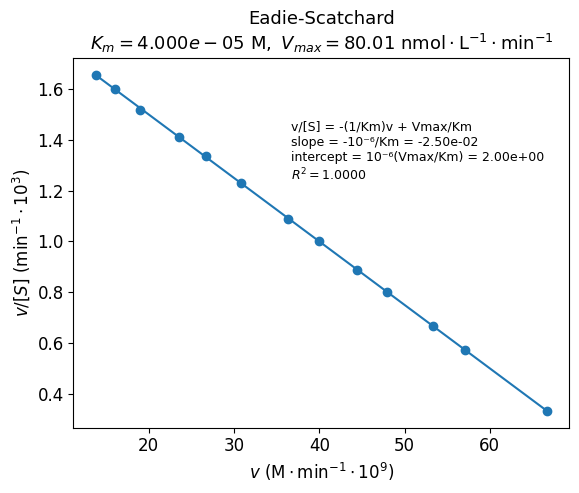

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

# ==========================================================
# Data
# ==========================================================

S = np.array([
    8.33e-6, 1.00e-5, 1.25e-5, 1.67e-5,
    2.00e-5, 2.50e-5, 3.33e-5, 4.00e-5,
    5.00e-5, 6.00e-5, 8.00e-5, 1.00e-4,
    2.00e-4
])

v = np.array([
    13.8, 16.0, 19.0, 23.6, 26.7, 30.8,
    36.3, 40.0, 44.4, 48.0, 53.4, 57.1,
    66.7
])

def fit_line(x, y):
    m, b = np.polyfit(x, y, 1)
    yhat = m*x + b
    r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
    return m, b, r2

# ==========================================================
# Scaled values matching textbook tables
# ==========================================================

S_s = S * 1e5
v_s = v

invS_s = (1 / S) * 1e-4
invv_s = (1 / v) * 100

v_by_S_s = (v / S) * 1e-6
S_by_v_s = (S / v) * 1e6

# ==========================================================
# 1) Lineweaver-Burk
# ==========================================================

x = invS_s
y = invv_s

m, b, r2 = fit_line(x, y)

Vmax = 100 / b
Km = (m * Vmax) / 1e6

plt.figure()

plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel(r"$1/[S]\ (\mathrm{M}^{-1} \cdot 10^{-4})$")
plt.ylabel(r"$1/v\ (\mathrm{M}^{-1} \cdot \mathrm{min} \cdot 10^{-7})$")

plt.title(
    rf"Lineweaver-Burk"
    "\n"
    rf"$K_m = {Km:.3e}\ \mathrm{{M}},\ "
    rf"V_{{max}} = {Vmax:.2f}\ \mathrm{{nmol \cdot L^{{-1}} \cdot min^{{-1}}}}$"
)

plt.text(
    0.20 * max(x),
    0.75 * max(y),
    "1/v = (Km/Vmax)(1/[S]) + 1/Vmax\n"
    f"slope = {m:.2e}\n"
    f"intercept = {b:.2e}\n"
    f"$R^2 = {r2:.4f}$",
    fontsize=9
)

plt.show()

# ==========================================================
# 2) Hanes-Woolf
# ==========================================================

x = S_s
y = S_by_v_s

m, b, r2 = fit_line(x, y)

Vmax = 10 / m
Km = (b * Vmax) / 1e6

plt.figure()

plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel(r"$[S]\ (\mathrm{M} \cdot 10^{5})$")
plt.ylabel(r"$[S]/v\ (\mathrm{min} \cdot 10^{-3})$")

plt.title(
    rf"Hanes-Woolf"
    "\n"
    rf"$K_m = {Km:.3e}\ \mathrm{{M}},\ "
    rf"V_{{max}} = {Vmax:.2f}\ \mathrm{{nmol \cdot L^{{-1}} \cdot min^{{-1}}}}$"
)

plt.text(
    0.25 * max(x),
    0.75 * max(y),
    "[S]/v = (1/Vmax)[S] + Km/Vmax\n"
    f"slope = {m:.2e}\n"
    f"intercept = {b:.2e}\n"
    f"$R^2 = {r2:.4f}$",
    fontsize=9
)

plt.show()

# ==========================================================
# 3) Eadie-Hofstee
# ==========================================================

x = v_by_S_s
y = v_s

m, b, r2 = fit_line(x, y)

Vmax = b
Km = -m / 1e6

plt.figure()

plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel(r"$v/[S]\ (\mathrm{min}^{-1} \cdot 10^{3})$")
plt.ylabel(r"$v\ (\mathrm{M} \cdot \mathrm{min}^{-1} \cdot 10^{9})$")

plt.title(
    rf"Eadie-Hofstee"
    "\n"
    rf"$K_m = {Km:.3e}\ \mathrm{{M}},\ "
    rf"V_{{max}} = {Vmax:.2f}\ \mathrm{{nmol \cdot L^{{-1}} \cdot min^{{-1}}}}$"
)

plt.text(
    0.25 * max(x),
    0.20 * max(y),
    "v = -Km(v/[S]) + Vmax\n"
    f"slope = {m:.2e}\n"
    f"intercept = {b:.2e}\n"
    f"$R^2 = {r2:.4f}$",
    fontsize=9
)

plt.show()

# ==========================================================
# 4) Direct Linear Transform
# ==========================================================

x = S_by_v_s
y = S_s

m, b, r2 = fit_line(x, y)

Vmax = 10 * m
Km = -b / 1e5

plt.figure()

plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel(r"$[S]/v\ (\mathrm{min} \cdot 10^{-3})$")
plt.ylabel(r"$[S]\ (\mathrm{M} \cdot 10^{5})$")

plt.title(
    rf"Direct Linear Transform"
    "\n"
    rf"$K_m = {Km:.3e}\ \mathrm{{M}},\ "
    rf"V_{{max}} = {Vmax:.2f}\ \mathrm{{nmol \cdot L^{{-1}} \cdot min^{{-1}}}}$"
)

plt.text(
    0.25 * max(x),
    0.75 * max(y),
    "[S] = Vmax([S]/v) - Km\n"
    f"slope = {m:.2e}\n"
    f"intercept = {b:.2e}\n"
    f"$R^2 = {r2:.4f}$",
    fontsize=9
)

plt.show()

# ==========================================================
# 5) Eadie-Scatchard
# ==========================================================

v_M = v * 1e-9

v_s = v_M * 1e9
v_by_S_s = (v_M / S) * 1e3

x = v_s
y = v_by_S_s

m, b, r2 = fit_line(x, y)

Km = -1e-6 / m
Vmax = (b * Km) / 1e-6

plt.figure()

plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel(r"$v\ (\mathrm{M} \cdot \mathrm{min}^{-1} \cdot 10^{9})$")
plt.ylabel(r"$v/[S]\ (\mathrm{min}^{-1} \cdot 10^{3})$")

plt.title(
    rf"Eadie-Scatchard"
    "\n"
    rf"$K_m = {Km:.3e}\ \mathrm{{M}},\ "
    rf"V_{{max}} = {Vmax:.2f}\ \mathrm{{nmol \cdot L^{{-1}} \cdot min^{{-1}}}}$"
)

plt.text(
    0.55 * max(x),
    0.75 * max(y),
    "v/[S] = -(1/Km)v + Vmax/Km\n"
    f"slope = -10⁻⁶/Km = {m:.2e}\n"
    f"intercept = 10⁻⁶(Vmax/Km) = {b:.2e}\n"
    f"$R^2 = {r2:.4f}$",
    fontsize=9
)

plt.show()